# EDA Phase 6: Missingness, Data Quality, and Dataset Audit

**Project:** CycleInsight  
**Dataset:** `datasets/cleaned_dataset.csv`  
**Scope:** Descriptive inventory and quality checks of the stored dataset. No predictive modeling, feature engineering, clustering, or statistical testing is performed. Flags are review prompts, not automatic judgments that a value is incorrect.


## Imports

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


## Configuration

In [5]:
# Resolve project paths when launched from either the repository root or notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "datasets" / "cleaned_dataset.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# These are identifiers/index-like fields, not continuous measurements for IQR review.
NON_MEASURE_NUMERIC = {"id", "day_in_study", "study_interval"}
NEAR_CONSTANT_SHARE = 0.95
TOP_MISSING_COLUMNS = 25

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})


## Helper functions

In [7]:
def save_figure(fig, filename):
    """Apply tight layout and save a readable figure in reports/figures."""
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def build_missingness_table(data):
    """Return missing counts and percentages for every column."""
    missing_count = data.isna().sum()
    return pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": (100 * missing_count / len(data)).round(2),
        "observed_count": len(data) - missing_count,
    }).sort_values(["missing_count", "missing_percent"], ascending=False)


def canonical_text(value):
    """Normalize text only for consistency auditing; do not modify source values."""
    if pd.isna(value):
        return pd.NA
    return " ".join(str(value).strip().casefold().split())


def numeric_summary(data):
    """Describe numeric columns and flag non-finite or negative observations."""
    numeric = data.select_dtypes(include="number")
    records = []
    for column in numeric.columns:
        values = numeric[column].dropna()
        finite_values = values[np.isfinite(values)]
        records.append({
            "column": column,
            "non_missing_n": int(values.size),
            "missing_n": int(data[column].isna().sum()),
            "min": finite_values.min() if not finite_values.empty else np.nan,
            "q1": finite_values.quantile(0.25) if not finite_values.empty else np.nan,
            "median": finite_values.median() if not finite_values.empty else np.nan,
            "q3": finite_values.quantile(0.75) if not finite_values.empty else np.nan,
            "max": finite_values.max() if not finite_values.empty else np.nan,
            "negative_n": int((finite_values < 0).sum()),
            "non_finite_n": int((~np.isfinite(values)).sum()),
        })
    return pd.DataFrame(records).set_index("column")


def iqr_outlier_table(data):
    """Count Tukey-fence observations per numeric measurement; this is not an error label."""
    numeric = data.select_dtypes(include="number").drop(columns=list(NON_MEASURE_NUMERIC), errors="ignore")
    rows = []
    for column in numeric.columns:
        values = numeric[column].dropna()
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        spread = q3 - q1
        lower_fence = q1 - 1.5 * spread
        upper_fence = q3 + 1.5 * spread
        outside = (values < lower_fence) | (values > upper_fence)
        rows.append({
            "column": column,
            "n": len(values),
            "lower_fence": lower_fence,
            "upper_fence": upper_fence,
            "outlier_count": int(outside.sum()),
            "outlier_percent": 100 * outside.mean(),
        })
    return pd.DataFrame(rows).set_index("column").sort_values("outlier_count", ascending=False)


## Dataset overview

In [9]:
# Load once, then use DataFrames for every audit summary.
df = pd.read_csv(DATA_PATH)

dataset_overview = pd.DataFrame({
    "value": {
        "rows": len(df),
        "columns": df.shape[1],
        "participants": df["id"].nunique(dropna=True) if "id" in df.columns else np.nan,
        "numeric_columns": len(df.select_dtypes(include="number").columns),
        "text_or_category_columns": len(df.select_dtypes(include=["object", "string", "category"]).columns),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "total_missing_cells": int(df.isna().sum().sum()),
    }
})
display(dataset_overview)

dtype_inventory = df.dtypes.astype(str).value_counts().rename_axis("dtype").to_frame("column_count")
display(dtype_inventory)


,value
rows,2937
columns,72
participants,42
numeric_columns,41
text_or_category_columns,31
exact_duplicate_rows,0
total_missing_cells,7


,column_count
dtype,
object,31
float64,23
int64,18


## Dataset integrity checks

Check structural integrity without changing the data: duplicate column names, fully empty rows or columns, missing identifiers, duplicate records, and duplicate participant/day keys. Key checks are only run when the relevant fields exist.

In [16]:
integrity_rows = [
    {"check": "duplicate column names", "count": int(df.columns.duplicated().sum())},
    {"check": "exact duplicate rows", "count": int(df.duplicated().sum())},
    {"check": "fully empty rows", "count": int(df.isna().all(axis=1).sum())},
    {"check": "fully empty columns", "count": int(df.isna().all(axis=0).sum())},
]
if "id" in df.columns:
    integrity_rows.append({"check": "missing participant IDs", "count": int(df["id"].isna().sum())})
if {"id", "day_in_study"}.issubset(df.columns):
    integrity_rows.append({
        "check": "duplicate participant/day keys",
        "count": int(df.duplicated(["id", "day_in_study"]).sum()),
    })
integrity_checks = pd.DataFrame(integrity_rows).set_index("check")
display(integrity_checks)


,count
check,
duplicate column names,0
exact duplicate rows,0
fully empty rows,0
fully empty columns,0
missing participant IDs,0
duplicate participant/day keys,0


## Missingness analysis

Missingness is reported as counts and percentages of dataset rows, column by column. The plot shows the most incomplete fields so labels remain readable.

,missing_count,missing_percent,observed_count
mood,2,0.07,2935
hygiene_product_used,2,0.07,2935
sorebreasts,1,0.03,2936
Cervical mucus code,1,0.03,2936
phase.1,1,0.03,2936
...,...,...,...
advice_text,0,0.00,2937
advice_type,0,0.00,2937
advice_source,0,0.00,2937
advice_confidence,0,0.00,2937


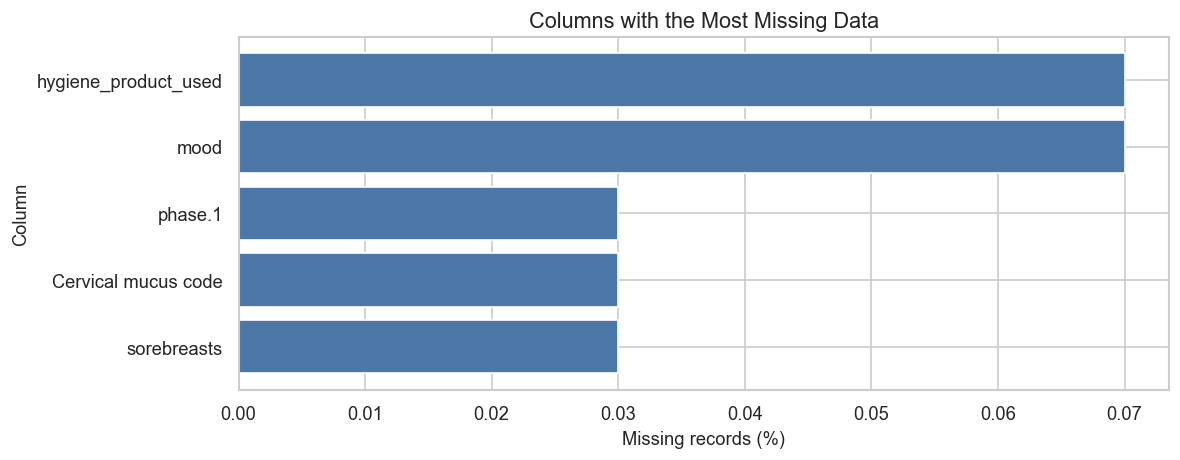

In [20]:
missingness = build_missingness_table(df)
display(missingness)

plot_missing = missingness.query("missing_count > 0").head(TOP_MISSING_COLUMNS).sort_values("missing_percent")
fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(plot_missing))))
if not plot_missing.empty:
    ax.barh(plot_missing.index, plot_missing["missing_percent"], color="#4C78A8")
ax.set(title="Columns with the Most Missing Data", xlabel="Missing records (%)", ylabel="Column")
save_figure(fig, "eda6_missingness_by_column.png")


## Missingness by participant

For each participant, summarize the share of cells missing across the available fields. This is a broad completeness measure and can be affected by columns that are not relevant to every participant.

,missing_cell_percent,records
count,42.000,42.000
mean,0.004,69.929
std,0.012,19.209
min,0.000,11.000
25%,0.000,57.250
50%,0.000,77.000
75%,0.000,85.750
max,0.063,89.000


,missing_cell_percent,records
id,,
4,0.063,45
7,0.032,89
3,0.024,58
6,0.022,63
38,0.017,84
1,0.000,74
41,0.000,86
32,0.000,47
33,0.000,88


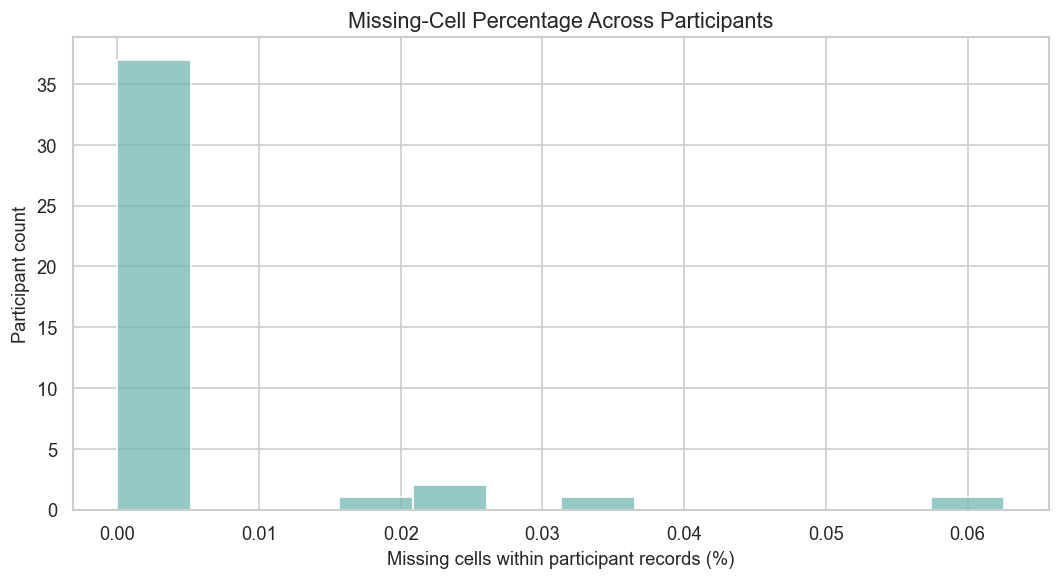

In [24]:
if "id" in df.columns:
    participant_missingness = df.groupby("id").apply(
        lambda group: group.isna().to_numpy().sum() / group.size * 100,
        include_groups=False,
    ).rename("missing_cell_percent").to_frame()
    participant_missingness["records"] = df.groupby("id").size()
    participant_missingness = participant_missingness.sort_values("missing_cell_percent", ascending=False)
    display(participant_missingness.describe().round(3))
    display(participant_missingness.head(10).round(3))

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(participant_missingness["missing_cell_percent"], bins=12, color="#72B7B2", ax=ax)
    ax.set(title="Missing-Cell Percentage Across Participants", xlabel="Missing cells within participant records (%)", ylabel="Participant count")
    save_figure(fig, "eda6_missingness_by_participant.png")
else:
    participant_missingness = pd.DataFrame()
    print("Participant missingness skipped: no `id` field is available.")


## Constant and near-constant feature audit

A constant field has one non-missing value. A near-constant field has one value in at least the configured share of non-missing records. These thresholds identify low-variation columns for review; they do not establish that a field should be removed.

In [28]:
variation_rows = []
for column in df.columns:
    counts = df[column].value_counts(dropna=True)
    non_missing_n = int(counts.sum())
    top_share = float(counts.iloc[0] / non_missing_n) if non_missing_n else np.nan
    unique_n = int(counts.size)
    if unique_n <= 1:
        audit_label = "constant" if unique_n == 1 else "all missing"
    elif top_share >= NEAR_CONSTANT_SHARE:
        audit_label = "near-constant"
    else:
        audit_label = "varies"
    variation_rows.append({
        "column": column,
        "non_missing_n": non_missing_n,
        "unique_non_missing": unique_n,
        "most_common_value": counts.index[0] if non_missing_n else pd.NA,
        "most_common_share": top_share,
        "audit_label": audit_label,
    })
variation_audit = pd.DataFrame(variation_rows).set_index("column").sort_values(
    ["audit_label", "most_common_share"], ascending=[True, False]
)
display(variation_audit.query("audit_label != 'varies'").round(4))


,non_missing_n,unique_non_missing,most_common_value,most_common_share,audit_label
column,,,,,
study_interval,2937,1,2022,1.0000,constant
type,2937,1,SKIN,1.0000,constant
synthetic_augmented_flag,2937,1,1,1.0000,constant
advice_source,2937,1,synthetic_augmented,1.0000,constant
validator_flag,2937,1,0,1.0000,constant
heavy_bleeding_flag_proxy,2937,6,0.0,0.9983,near-constant
missing_mnar_flag,2937,3,0.0,0.9748,near-constant
missing_mar_flag,2937,2,0,0.9694,near-constant


## Category consistency audit

For text-like columns, compare stored spellings with a canonicalized view that trims surrounding whitespace, collapses repeated spaces, and ignores case. Original values are left unchanged. Variant groups are audit cues for review, not automatic replacements.

In [32]:
text_columns = df.select_dtypes(include=["object", "string", "category"]).columns
category_rows = []
variant_rows = []
for column in text_columns:
    values = df[column].dropna()
    normalized = values.map(canonical_text)
    category_rows.append({
        "column": column,
        "non_missing_n": len(values),
        "stored_unique_values": int(values.nunique()),
        "canonical_unique_values": int(normalized.nunique()),
        "possible_format_variants": int(values.nunique() - normalized.nunique()),
    })
    variants = pd.DataFrame({"stored_value": values.astype(str), "canonical_value": normalized.astype(str)})
    for canonical_value, group in variants.groupby("canonical_value"):
        stored_values = group["stored_value"].value_counts()
        if len(stored_values) > 1:
            for stored_value, count in stored_values.items():
                variant_rows.append({
                    "column": column,
                    "canonical_value": canonical_value,
                    "stored_value": stored_value,
                    "count": int(count),
                    "variant_count": len(stored_values),
                })
category_audit = pd.DataFrame(category_rows).set_index("column").sort_values(
    ["possible_format_variants", "stored_unique_values"], ascending=False
)
category_variants = pd.DataFrame(variant_rows)
display(category_audit)
display(category_variants)


,non_missing_n,stored_unique_values,canonical_unique_values,possible_format_variants
column,,,,
cultural_preferences,2937,8,5,3
pain_location,2937,11,10,1
hygiene_product_used,2935,6,5,1
Cervical mucus code,2936,5,4,1
sleep_end_timestamp,2937,918,918,0
sleep_start_timestamp,2937,880,880,0
flow_color,2937,9,9,0
flow intensity,2937,8,8,0
contraception_type,2937,7,7,0


,column,canonical_value,stored_value,count,variant_count
0,Cervical mucus code,creamy,Creamy,744,2
1,Cervical mucus code,creamy,Creamy,1,2
2,pain_location,not at all,Not at all,2321,2
3,pain_location,not at all,not at all,68,2
4,hygiene_product_used,not at all,Not at all,2258,2
5,hygiene_product_used,not at all,not at all,88,2
6,cultural_preferences,not at all,Not at all,2268,2
7,cultural_preferences,not at all,not at all,107,2
8,cultural_preferences,pads,Pads,154,2
9,cultural_preferences,pads,pads,10,2


## Numeric range audit

Summarize stored numeric ranges, quartiles, missing values, negative observations, and non-finite values. No clinical or domain-specific validity limits are imposed here; unusual values should be checked against field definitions and source provenance.

In [36]:
numeric_ranges = numeric_summary(df)
display(numeric_ranges.round(4))


,non_missing_n,missing_n,min,q1,median,q3,max,negative_n,non_finite_n
column,,,,,,,,,
id,2937,0,1.0000,12.0000,24.0000,40.0000,50.0000,0,0
age,2937,0,18.0000,19.0000,20.0000,23.0000,29.0000,0,0
study_interval,2937,0,2022.0000,2022.0000,2022.0000,2022.0000,2022.0000,0,0
day_in_study,2937,0,1.0000,20.0000,41.0000,64.0000,90.0000,0,0
bleeding_days,2937,0,0.0000,0.0000,0.0000,0.0000,12.0000,0,0
lh,2937,0,0.0000,2.4000,3.6000,5.4000,97.0000,0,0
estrogen,2937,0,0.0000,66.4000,106.4000,172.2000,640.0000,0,0
sleep_start_day_in_study,2937,0,1.0000,40.0000,89.0000,920.0000,1004.0000,0,0
sleep_end_day_in_study,2937,0,1.0000,41.0000,90.0000,920.0000,1004.0000,0,0


## IQR outlier summary

The IQR summary counts values outside Q1 − 1.5×IQR and Q3 + 1.5×IQR. These distribution-based flags are descriptive and do not mean that an observation is erroneous. Identifier and study-index fields are omitted from this summary.

,n,lower_fence,upper_fence,outlier_count,outlier_percent
column,,,,,
access_to_clean_water,2937,1.000,1.000,731,24.889
anovulation_proxy,2937,1.000,1.000,654,22.268
bleeding_days,2937,0.000,0.000,568,19.339
comorbid_PCOS,2937,0.000,0.000,259,8.819
lh,2937,-2.100,9.900,248,8.444
BMI,2937,11.524,33.710,243,8.274
baseline_relative_nightly_standard_deviation,2937,0.144,0.995,196,6.673
baseline_relative_sample_sum_of_squares,2937,-510.850,1807.697,188,6.401
estrogen,2937,-92.300,330.900,175,5.958


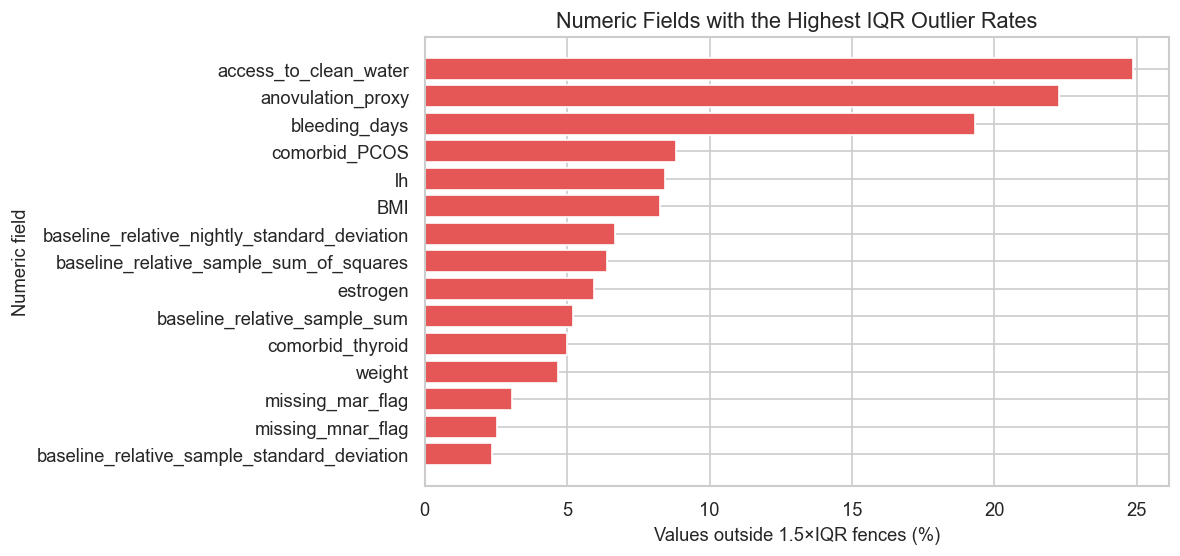

In [40]:
iqr_outliers = iqr_outlier_table(df)
display(iqr_outliers.round(3))
plot_outliers = iqr_outliers.query("outlier_count > 0").head(15).sort_values("outlier_percent")
fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(plot_outliers))))
if not plot_outliers.empty:
    ax.barh(plot_outliers.index, plot_outliers["outlier_percent"], color="#E45756")
ax.set(title="Numeric Fields with the Highest IQR Outlier Rates", xlabel="Values outside 1.5×IQR fences (%)", ylabel="Numeric field")
save_figure(fig, "eda6_iqr_outlier_rates.png")


## Potential leakage/derived-feature audit

Inventory columns that appear label-like, outcome-like, generated, advice-related, proxy-derived, or calculated from temporal measurements. This is a name- and context-based audit only: confirm definitions and provenance before using any such fields in later work. No fields are altered or newly constructed.

In [44]:
# Candidate roles are explicitly documented as review prompts based on existing field names.
AUDIT_CANDIDATES = {
    "Potential target or outcome labels": ["HMB_label"],
    "Proxy or rule-derived indicators": ["heavy_bleeding_flag_proxy", "anovulation_proxy", "validator_flag"],
    "Synthetic-data provenance": ["synthetic_augmented_flag", "advice_source"],
    "Generated advice outputs": ["advice_text", "advice_type", "advice_confidence"],
    "Lagged or rolling summaries": ["lag1_BBT", "lag2_BBT", "BBT_mean_7d", "BBT_std_7d"],
    "Baseline-relative aggregates": [
        "baseline_relative_sample_sum", "baseline_relative_sample_sum_of_squares",
        "baseline_relative_nightly_standard_deviation", "baseline_relative_sample_standard_deviation",
    ],
    "Duplicate or parallel phase field": ["phase.1"],
}

derived_audit_rows = []
for candidate_group, candidates in AUDIT_CANDIDATES.items():
    for column in candidates:
        if column in df.columns:
            derived_audit_rows.append({
                "column": column,
                "candidate_group": candidate_group,
                "non_missing_n": int(df[column].notna().sum()),
                "unique_non_missing": int(df[column].nunique(dropna=True)),
                "audit_note": "Confirm definition, generation time, and intended use before downstream analysis.",
            })
derived_feature_audit = pd.DataFrame(derived_audit_rows).set_index("column")
display(derived_feature_audit)


,candidate_group,non_missing_n,unique_non_missing,audit_note
column,,,,
HMB_label,Potential target or outcome labels,2937,91,"Confirm definition, generation time, and inten..."
heavy_bleeding_flag_proxy,Proxy or rule-derived indicators,2937,6,"Confirm definition, generation time, and inten..."
anovulation_proxy,Proxy or rule-derived indicators,2937,2,"Confirm definition, generation time, and inten..."
validator_flag,Proxy or rule-derived indicators,2937,1,"Confirm definition, generation time, and inten..."
synthetic_augmented_flag,Synthetic-data provenance,2937,1,"Confirm definition, generation time, and inten..."
advice_source,Synthetic-data provenance,2937,1,"Confirm definition, generation time, and inten..."
advice_text,Generated advice outputs,2937,7,"Confirm definition, generation time, and inten..."
advice_type,Generated advice outputs,2937,2,"Confirm definition, generation time, and inten..."
advice_confidence,Generated advice outputs,2937,5,"Confirm definition, generation time, and inten..."


## Data quality scorecard

The scorecard summarizes checks as **Review** or **No issue detected by this check**. It is not a single numeric quality grade: completeness, consistency, unusual ranges, and field provenance measure different things.

In [48]:
noncanonical_category_columns = int((category_audit["possible_format_variants"] > 0).sum()) if not category_audit.empty else 0
constant_columns = int((variation_audit["audit_label"] == "constant").sum())
near_constant_columns = int((variation_audit["audit_label"] == "near-constant").sum())
review_candidates = len(derived_feature_audit)
scorecard = pd.DataFrame([
    {"area": "Structure", "status": "Review" if integrity_checks["count"].sum() else "No issue detected by this check", "evidence": f"{int(integrity_checks['count'].sum())} structural check findings across {len(integrity_checks)} checks"},
    {"area": "Missingness", "status": "Review" if int(df.isna().sum().sum()) else "No issue detected by this check", "evidence": f"{int(df.isna().sum().sum())} missing cells across {int((df.isna().sum() > 0).sum())} columns"},
    {"area": "Low variation", "status": "Review" if constant_columns + near_constant_columns else "No issue detected by this check", "evidence": f"{constant_columns} constant and {near_constant_columns} near-constant columns at {NEAR_CONSTANT_SHARE:.0%} threshold"},
    {"area": "Category formatting", "status": "Review" if noncanonical_category_columns else "No issue detected by this check", "evidence": f"{noncanonical_category_columns} text columns have case/whitespace variants"},
    {"area": "Numeric distribution", "status": "Review" if not iqr_outliers.empty and (iqr_outliers["outlier_count"] > 0).any() else "No issue detected by this check", "evidence": f"{int((iqr_outliers['outlier_count'] > 0).sum()) if not iqr_outliers.empty else 0} numeric columns contain IQR flags"},
    {"area": "Potential derived/output fields", "status": "Review" if review_candidates else "No issue detected by this check", "evidence": f"{review_candidates} candidate fields listed for provenance review"},
]).set_index("area")
display(scorecard)


,status,evidence
area,,
Structure,No issue detected by this check,0 structural check findings across 6 checks
Missingness,Review,7 missing cells across 5 columns
Low variation,Review,5 constant and 3 near-constant columns at 95% ...
Category formatting,Review,4 text columns have case/whitespace variants
Numeric distribution,Review,21 numeric columns contain IQR flags
Potential derived/output fields,Review,18 candidate fields listed for provenance review


## Key findings

### Key Findings

- The dataset contains **2,937 records and 72 columns**. The participant/day key is unique and no exact duplicate rows were found.
- Missing values are sparse: **7 cells across five columns** (`mood`, `hygiene_product_used`, `phase.1`, `sorebreasts`, and `Cervical mucus code`).
- The text field `Cervical mucus code` contains a whitespace variant (`Creamy` / ` Creamy`); `Cervical mucus code`, `pain_location`, `hygiene_product_used`, and `cultural_preferences` contain case or whitespace variants according to the normalization audit.
- `type` is constant across the dataset. Numeric range and IQR tables flag values that merit definition-level review, including a `pain_nrs` maximum of **33**; this is a data-range observation, not a conclusion about validity.
- Several columns are potential labels, proxies, derived measurements, synthetic-data markers, or generated advice. Their presence warrants source and timing review before later analytical use.

### Data Quality Notes

- Category normalization was used only to identify likely formatting variants; source values remain unchanged.
- IQR flags are distribution-based and are not errors. Numeric bounds have not been judged against clinical or domain assumptions.
- The leakage/derived-feature inventory is a manual candidate list based on field names and dataset context. It does not prove leakage or establish lineage.
- This notebook reports DataFrames for review and saves descriptive plots; it does not impute, recode, remove, or create dataset features.

### Recommended Next Step

Confirm the definitions and provenance of label-like, proxy, advice, and derived fields, then document a field-level inclusion policy before using this dataset in downstream analyses.
